# Pick one map + one model -> dynamic-LRP heatmap

Hands-on notebook: **load an image, run the model of your choice, see the
attribution heatmap.** Edit the three values in the **CONFIG** cell, then run the
cells top to bottom.

**Hardware (hard constraint):** single NVIDIA L4, ~22.5 GB usable VRAM. Only one
model is held in VRAM at a time -- re-running the *load* cell frees the previous
model first. The dynamic-LRP relevance pass is memory-heavy (ViT-b-16 peaks
~19.3 GB).

**Models:** `vit_b16` is the known-good positive control (real heatmaps).
`siglip2` / `clip` hit dynamic-LRP op-coverage gaps and show "no heatmap".
`paligemma` (3B) is the heaviest and may OOM the relevance pass. A model
dynamic-LRP can't traverse is an honest "no heatmap" result, not a crash.

In [34]:
# ====================== CONFIG -- edit me ======================
MODEL_NAME = "siglip2"            # "vit_b16" | "siglip2" | "clip" | "paligemma"
MAP_INDEX  = -1                   # index into the Rumsey manifest (-1 = last / richest)
QUERY      = "A forest on a map"   # text query (siglip2/clip/paligemma); mapped to an
                                  # ImageNet class for vit_b16 (it has no text tower)
# ===============================================================
print("config:", MODEL_NAME, "| map index", MAP_INDEX, "| query", repr(QUERY))

config: siglip2 | map index -1 | query 'A forest on a map'


In [35]:
# Setup: path wiring, imports, device + vendored-engine integrity check.
import sys, gc
from pathlib import Path

_REPO_ROOT = Path.cwd()
if not (_REPO_ROOT / "notebooks").exists() and _REPO_ROOT.name == "notebooks":
    _REPO_ROOT = _REPO_ROOT.parent
for _p in (_REPO_ROOT / "third_party" / "dynamicLRP" / "src", _REPO_ROOT / "src"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import torch
import matplotlib.pyplot as plt
from mapclass import config

assert torch.cuda.is_available(), "CUDA required -- run on the GPU VM (CLAUDE.md)."
_sha = (_REPO_ROOT / "third_party" / "dynamicLRP" / "VENDOR_SHA").read_text().strip()
assert config.VENDOR_SHA == _sha, "vendored dynamicLRP SHA drift -- do not proceed"

def vram_gb():
    return torch.cuda.memory_allocated() / 1024**3

print("device :", torch.cuda.get_device_name(0),
      f"| {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB total")
print("VRAM in use :", f"{vram_gb():.2f} GB")

device : NVIDIA L4 | 22.0 GB total
VRAM in use : 6.15 GB


map id : RUMSEY~8~1~318544~90087523
index  : 444  (of 1544)
size   : (1536, 1020)


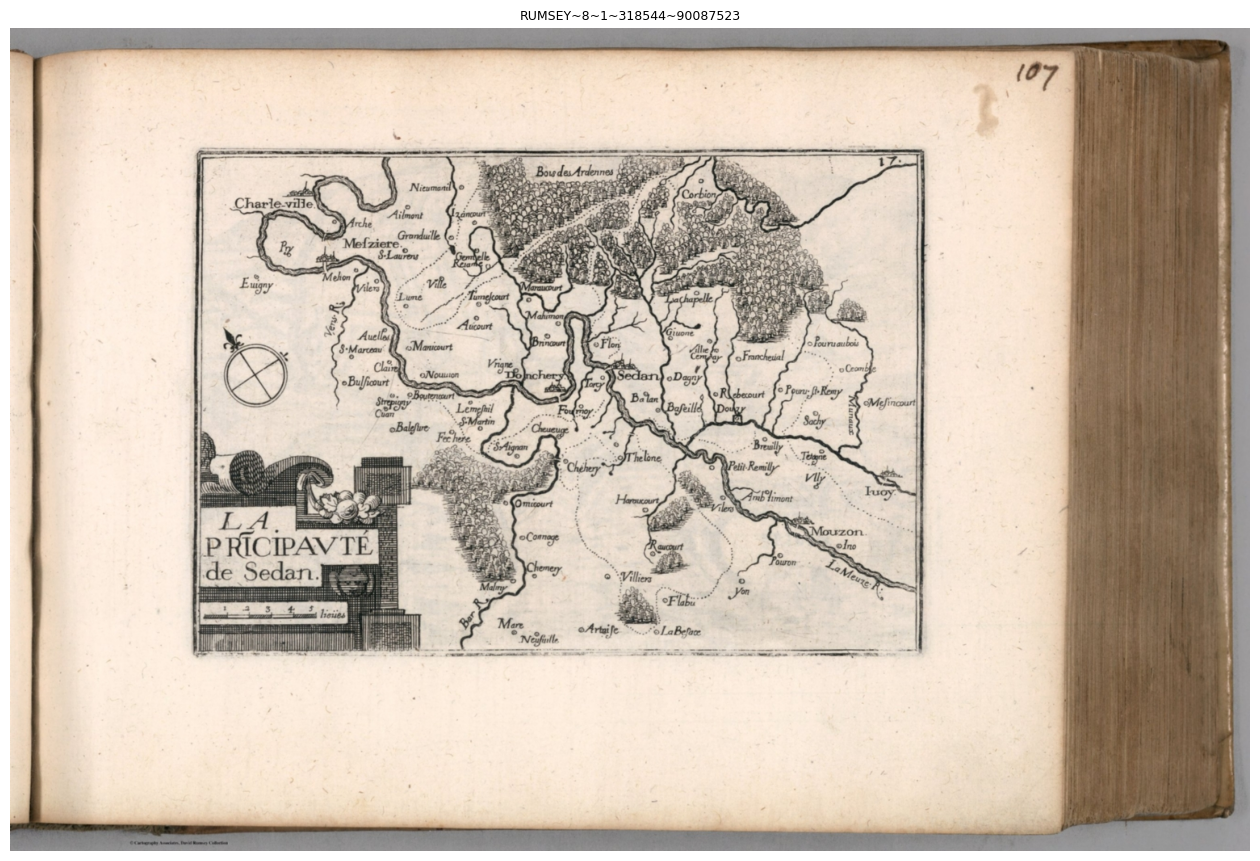

In [36]:
# Step 1 -- load the image.
from PIL import Image
from mapclass.manifest import load_manifest, entry_by_index
from mapclass.data_loader import _cached_image_path

manifest = load_manifest() # Manifest has 1544 indices. MAP_INDEX is -1 by default
MAP_INDEX = 444  #  150 good detail, 444 great features, 1444 wierd style
entry = entry_by_index(manifest, MAP_INDEX)
pil = Image.open(_cached_image_path(entry["id"])).convert("RGB")
print(f"map id : {entry['id']}")
print(f"index  : {MAP_INDEX}  (of {len(manifest)})")
print(f"size   : {pil.size}")

fig, ax = plt.subplots(figsize=(16, 16))
ax.imshow(pil); ax.set_axis_off(); ax.set_title(entry["id"], fontsize=9)
plt.show()

In [37]:
manifest[444]

{'id': 'RUMSEY~8~1~318544~90087523',
 'title': 'RUMSEY~8~1~318544~90087523',
 'date': '1636',
 'author': 'Tassin, Christophe Nicolas, 1660-1641',
 'publisher': 'Melchior Tavernier',
 'publisher_location': 'Paris',
 'country': 'France',
 'world_area': None,
 'region': 'Champagne Region, (France)',
 'city': 'Sedan (France)',
 'scale': '151,952',
 'obj_height_cm': '11',
 'obj_width_cm': '15',
 'full_title': 'La Pricipavte de Sedan. (to accompany) Les plans et profils de tovtes les principales villes et lievx considerables de France ... Par le Sieur Tassin. A Paris, M. DC. XXXVI (1636).',
 'reference': None,
 'richness_score': 11,
 'thumbnail_url': 'https://www.davidrumsey.com/rumsey/Size0/RUMSEY~8~1/179/13303091.jpg',
 'image_url': 'https://media.davidrumsey.com/MediaManager/srvr?mediafile=/Size4/RUMSEY~8~1/179/13303091.jpg',
 'iiif_manifest': 'https://www.davidrumsey.com/luna/servlet/iiif/m/RUMSEY~8~1~318544~90087523/manifest',
 'rumsey_page': 'https://www.davidrumsey.com/luna/servlet/de

In [38]:
# Step 2 -- load the model of your choice. Frees a previously-loaded model first
# so only ONE model is ever resident in VRAM (L4 hard constraint).
from mapclass.models import MODEL_REGISTRY

assert MODEL_NAME in MODEL_REGISTRY, (
    f"unknown model {MODEL_NAME!r}; choose from {list(MODEL_REGISTRY)}"
)

# Free a model left over from a previous run of this cell, if any.
try:
    model.to("cpu"); del model, processor          # noqa: F821
except NameError:
    pass
gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

spec = MODEL_REGISTRY[MODEL_NAME]
geom = spec["patch_geom"]
model, processor = spec["load_fn"]()
try:
    model._mapclass_processor = processor          # PaliGemma target_fn needs it
except Exception:
    pass
print(f"loaded {MODEL_NAME!r} | patch_geom {geom} | VRAM now {vram_gb():.2f} GB")

loaded 'siglip2' | patch_geom {'patch_size': 14, 'img_dim': 384, 'has_cls': False} | VRAM now 10.28 GB


In [39]:
# Run the forward + dynamic-LRP relevance pass for (this image, this model).
# A coverage gap or OOM is caught and reported as "no heatmap" -- never a crash.
from mapclass.attribution import attribute
from mapclass import overlay as ovl

forward_inputs, img_tensor = spec["build_inputs_fn"](
    model, processor, pil, QUERY, config.DEVICE
)
forward_inputs_for_fwd = {k: v for k, v in forward_inputs.items()
                          if not k.startswith("_")}
forward_inputs["_query"] = QUERY        # ViT class-target reads this

result, fail = None, None
try:
    result = attribute(
        model, forward_inputs_for_fwd, img_tensor,
        lambda mdl, out, _fi, _f=spec["target_fn"]: _f(mdl, out, forward_inputs),
    )
    print(f"OK  target_form={result.target_form}  "
          f"similarity={result.similarity:.4f}  "
          f"peak_vram={(result.peak_vram_bytes or 0)/1024**3:.2f} GB")
except Exception as e:
    fail = f"{type(e).__name__}: {str(e)[:200]}"
    print("NO HEATMAP --", fail)

'DummyPromise' object is not iterable
No valid curnode candidate was found.
NO HEATMAP -- RuntimeError: LRPEngine.run rejected every target form (scalar_0d / slice_2d / reshape_1d). Last error: ValueError('too many values to unpack (expected 2)'). See the Fallback Ladder in this module's docstring (step


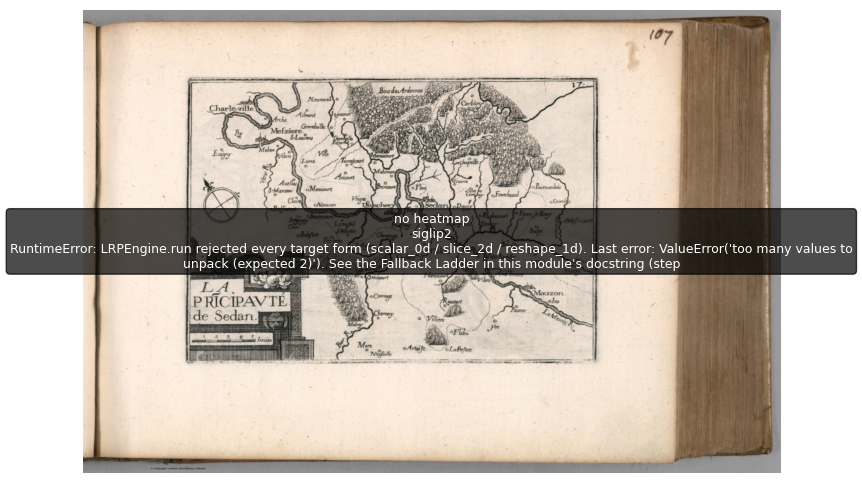

In [40]:
# Step 3 -- see it. Signed (D-09) zero-centered overlay on the map, or a
# captioned "no heatmap" tile if the relevance pass could not run.
fig, ax = plt.subplots(figsize=(9, 9))
if result is not None:
    gs, gm = ovl.to_patch_grid(
        result.relevance,
        patch_size=geom["patch_size"], img_dim=geom["img_dim"],
        has_cls=geom["has_cls"],
    )
    ovl.composite(
        ax, pil, gs, gm,
        title=f"{MODEL_NAME} | {entry['id']}\n"
              f"query={QUERY!r}  target={result.target_form}",
        interpolation="nearest",
    )
else:
    w, h = pil.size
    ax.imshow(pil, extent=(0, w, h, 0))
    ax.text(0.5, 0.5, f"no heatmap\n{MODEL_NAME}\n{fail}",
            transform=ax.transAxes, ha="center", va="center",
            fontsize=9, color="white",
            bbox=dict(boxstyle="round", facecolor="black", alpha=0.7), wrap=True)
    ax.set_axis_off()
plt.show()